# Network Analysis EDA

## Setup

In [2]:
# Import Packages
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import community
from networkx.algorithms import bipartite as nxb
from collections import Counter
from itertools import combinations
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import re
import math
from networkx.algorithms.community import greedy_modularity_communities
from typing import Optional
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("All libraries loaded")

All libraries loaded


In [3]:
df_conv = pd.read_parquet("../data_storage/final_data/final_dataset_with_attribution.parquet")

In [4]:
STOP = set(stopwords.words("english"))
LEMM = WordNetLemmatizer()

def preprocess_article_text_nltk(text: str) -> list[str]:
    """
    Lowercase → strip non-letters → tokenize by whitespace → remove stopwords/short tokens → lemmatize (noun).
    Keeps it lightweight for Python 3.13 compatibility (no POS tag requirement).
    """
    if not isinstance(text, str) or not text:
        return []
    txt = text.lower()
    txt = re.sub(r"[^a-z\s]", " ", txt)     
    toks = [t for t in txt.split() if len(t) > 2 and t not in STOP]
    
    toks = [LEMM.lemmatize(t) for t in toks]
    return toks

In [5]:
def build_tokens(attDF: pd.DataFrame, body_col: str = "article_body") -> pd.DataFrame:
    if body_col not in attDF.columns:
        raise KeyError(f"Column '{body_col}' not found in DataFrame.")
    out = attDF.copy()
    out["tokens"] = out[body_col].fillna("").apply(preprocess_article_text_nltk)
    out["keyword_counts"] = out["tokens"].apply(lambda toks: Counter(toks))
    return out

df_conv = build_tokens(df_conv, body_col="article_body")

In [6]:
df_conv.head()

,article_body,article_id,author_name,channel_name,circulation_size,feed_name,headline,hit_strength,publication_name,published_datetime,...,headline_token_count,body_token_count,token_count,seq_index,has_person,is_conversion,circulation_size_bin,sentiment_score_bin,tokens,keyword_counts
0,johannesburg south africa los angeles calif ja...,17875604184,unknown,web,800,opoint,scientology africa five year unconditional hel...,3,daily_journal,2024-01-20 11:54:19+00:00,...,13,510,523,0,True,True,CIRCULATION_SIZE_Q1,SENTIMENT_SCORE_Q5,"[johannesburg, south, africa, los, angeles, ca...","{'johannesburg': 3, 'south': 13, 'africa': 11,..."
1,news provided ein presswire apr london united ...,18122540973,unknown,web,1066890,opoint,health political choice advancing indigenous p...,7,wkrn,2024-04-07 14:13:13+00:00,...,10,357,367,1,True,True,CIRCULATION_SIZE_Q5,SENTIMENT_SCORE_Q5,"[news, provided, ein, presswire, apr, london, ...","{'news': 1, 'provided': 1, 'ein': 1, 'presswir..."
2,honor earth day chamber county community healt...,18172305397,charlotte_reames,web,14529,opoint,wellness center launch garden micro pantry ear...,2,valley_times_news,2024-04-23 14:16:06+00:00,...,8,202,210,2,True,True,CIRCULATION_SIZE_Q3,SENTIMENT_SCORE_Q5,"[honor, earth, day, chamber, county, community...","{'honor': 1, 'earth': 2, 'day': 2, 'chamber': ..."
3,cnn number measles case around world nearly do...,18186873367,katherine_dillinger,web,1038,opoint,global measles case nearly doubled one year re...,2,cnn_edition,2024-04-27 22:09:46+00:00,...,9,290,299,4,True,True,CIRCULATION_SIZE_Q2,SENTIMENT_SCORE_Q3,"[cnn, number, measles, case, around, world, ne...","{'cnn': 2, 'number': 3, 'measles': 14, 'case':..."
4,unpermitted hot dog stand outside moda center ...,18657093894,mike_rogoway_zane_sparling,web,285605,opoint,license grill illegal hot dog vendor hit amphi...,1,centralia_chronicle,2024-09-25 16:27:25+00:00,...,13,196,209,6,True,True,CIRCULATION_SIZE_Q4,SENTIMENT_SCORE_Q4,"[unpermitted, hot, dog, stand, outside, moda, ...","{'unpermitted': 3, 'hot': 1, 'dog': 1, 'stand'..."


In [7]:
### keyword frequency table 
def keyword_frequency_table(attDF: pd.DataFrame, tokens_col: str = "tokens") -> pd.DataFrame:
    if tokens_col not in df_conv.columns:
        raise KeyError(f"Column '{tokens_col}' not found in DataFrame.")
    kw = (df_conv.explode(tokens_col)
            .groupby(tokens_col)
            .size()
            .reset_index(name="frequency")
            .sort_values("frequency", ascending=False)
            .rename(columns={tokens_col: "keyword"}))
    return kw

keywords_df = keyword_frequency_table(df_conv)
display(keywords_df.head(25))

,keyword,frequency
92029,health,610310
191401,said,233709
176359,public,220398
165998,people,186334
243877,year,170802
57816,disease,170277
207666,state,141271
149978,new,139933
7368,also,130535
231302,vaccine,130443


## Analysis

In [22]:
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88347 entries, 0 to 88346
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype                         
---  ------                --------------  -----                         
 0   article_body          88347 non-null  string                        
 1   article_id            88347 non-null  Int64                         
 2   author_name           88347 non-null  string                        
 3   channel_name          88347 non-null  string                        
 4   circulation_size      88347 non-null  Int32                         
 5   feed_name             88347 non-null  string                        
 6   headline              88347 non-null  string                        
 7   hit_strength          88347 non-null  Int16                         
 8   publication_name      88347 non-null  string                        
 9   published_datetime    88347 non-null  timestamp[ns, tz=UTC][pyarrow]
 10

In [17]:
DF = df_conv
SOURCE_COL = "source_name"
TOPIC_COL  = "tag_name"

WEIGHT_BY = ["circulation_size", "vipr_weight", "hit_strength"]
WEIGHT_WEIGHTS = None   

MIN_EDGE_WEIGHT = 0.2
MIN_TOPICS_PER_SOURCE = 2
MIN_SOURCES_PER_TOPIC = 2
USE_TFIDF = True

EDGE_KEEP_PCT_BIP = 75
EDGE_KEEP_PCT_PROJ = 70
LABEL_SOURCES_TOP = 25
LABEL_TOPICS_TOP = 8

# 1) Rank-only combiner
def _combine_rankpct(df: pd.DataFrame, cols: list[str], weights: list[float] | None = None) -> pd.Series:
    """
    Percentile-rank each column to [0,1], then take a (weighted) mean across columns.
    Robust to scale/outliers. NaNs are filled with the column's mean rank.
    """
    X = df[cols].copy().replace([np.inf, -np.inf], np.nan)
    R = X.rank(pct=True, na_option="keep")
    R = R.fillna(R.mean())
    if weights is None:
        w = np.ones(len(cols), dtype=float)
    else:
        w = np.asarray(weights, dtype=float)
    s = w.sum()
    if s == 0:
        w = np.ones(len(cols), dtype=float)
        s = w.sum()
    w = w / s
    return (R * w).sum(axis=1)

# 2) Build bipartite graph
def build_source_topic_bipartite(
    df: pd.DataFrame,
    source_col: str = "source_type_name",
    topic_col: str = "tag_name",
    weight_by: str | list[str] = "count",
    weight_weights: list[float] | None = None,
    min_edge_weight: float = 0.2,
    min_topics_per_source: int = 2,
    min_sources_per_topic: int = 2,
    drop_na: bool = True,
    use_tfidf: bool = False,
    use_sum_instead_of_mean: bool = False  
):
    assert source_col in df.columns and topic_col in df.columns, "Missing source/topic columns."
    dd = df.copy()
    if drop_na:
        dd = dd.dropna(subset=[source_col, topic_col])

    # weights
    if isinstance(weight_by, str):
        if weight_by == "count":
            agg = dd.groupby([source_col, topic_col]).size().reset_index(name="weight")
        else:
            if weight_by not in dd.columns:
                raise ValueError(f"weight_by='{weight_by}' not found in DataFrame.")
            agg = dd.groupby([source_col, topic_col])[weight_by].sum(min_count=1).reset_index(name="weight")
    else:
        # list of columns blended via rank-pct
        for c in weight_by:
            if c not in dd.columns:
                raise ValueError(f"Column '{c}' in weight_by not found in DataFrame.")
        dd["__combined_weight__"] = _combine_rankpct(dd, weight_by, weights=weight_weights)
        grp = dd.groupby([source_col, topic_col])["__combined_weight__"]
        agg = (grp.sum() if use_sum_instead_of_mean else grp.mean()).reset_index(name="weight")

    # edge threshold
    agg = agg[agg["weight"] >= min_edge_weight].copy()
    if agg.empty:
        return nx.Graph(), agg, set(), set()

    # optional TF-IDF reweighting
    if use_tfidf:
        src_tot = agg.groupby(source_col)["weight"].transform("sum")
        agg["tf"] = agg["weight"] / src_tot
        topic_src_n = agg.groupby(topic_col)[source_col].transform("nunique")
        n_sources = agg[source_col].nunique()
        agg["idf"] = np.log((n_sources + 1) / (topic_src_n + 1)) + 1
        agg["weight"] = agg["tf"] * agg["idf"]
        agg = agg[[source_col, topic_col, "weight"]]

    # degree pruning
    keep_src = set(agg.groupby(source_col)[topic_col].nunique().pipe(lambda s: s[s >= min_topics_per_source].index))
    keep_top = set(agg.groupby(topic_col)[source_col].nunique().pipe(lambda s: s[s >= min_sources_per_topic].index))
    agg = agg[agg[source_col].isin(keep_src) & agg[topic_col].isin(keep_top)]
    if agg.empty:
        return nx.Graph(), agg, set(), set()

    # build graph
    B = nx.Graph()
    B.add_nodes_from(sorted(keep_src), bipartite=0, kind="source")
    B.add_nodes_from(sorted(keep_top), bipartite=1, kind="topic")
    B.add_weighted_edges_from(agg[[source_col, topic_col, "weight"]].itertuples(index=False, name=None))
    sources = {n for n, d in B.nodes(data=True) if d.get("bipartite") == 0}
    topics  = set(B) - sources
    return B, agg, sources, topics

In [18]:
# 3) Visual helpers
def _safe_bipartite_layout(G, left_nodes):
    try:
        return nxb.layout.bipartite_layout(G, left_nodes)
    except Exception:
        return nx.spring_layout(G, seed=42)

def visualize_bipartite(B, sources, topics, title="Sources ↔ Topics (Bipartite)",
                        label_sources_top=20, label_topics_top=0, edge_keep_pct=70):
    if B.number_of_nodes() == 0:
        print("Graph is empty."); return
    w = np.array([B[u][v].get("weight", 1) for u, v in B.edges()])
    thr = np.percentile(w, 100 - edge_keep_pct) if len(w) else 1
    H = nx.Graph()
    H.add_nodes_from(B.nodes(data=True))
    H.add_edges_from([(u, v, d) for u, v, d in B.edges(data=True) if d.get("weight", 1) >= thr])
    H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n) == 0])
    if H.number_of_nodes() == 0:
        print("No nodes after pruning."); return
    comps = list(nx.connected_components(H))
    H = H.subgraph(max(comps, key=len)).copy()

    left = [n for n in H.nodes if n in sources]
    right = [n for n in H.nodes if n in topics]
    if not left or not right:
        left = [n for n, d in H.nodes(data=True) if d.get("bipartite") == 0] or left
        right = [n for n, d in H.nodes(data=True) if d.get("bipartite") == 1] or right

    pos = _safe_bipartite_layout(H, left)
    strength = {n: sum(H[n][nbr].get("weight", 1) for nbr in H.neighbors(n)) for n in H.nodes()}
    size_map = {n: 80 + 12*np.log1p(s) for n, s in strength.items()}
    ewidths = [0.6 + np.log1p(H[u][v].get("weight", 1)) for u, v in H.edges()]

    plt.figure(figsize=(12, 8))
    nx.draw_networkx_edges(H, pos, width=ewidths, alpha=0.35)
    src_nodes = nx.draw_networkx_nodes(H, pos, nodelist=left, node_color="#3b82f6",
                                       node_size=[size_map[n] for n in left], label="Sources")
    top_nodes = nx.draw_networkx_nodes(H, pos, nodelist=right, node_color="#a78bfa",
                                       node_size=[size_map[n] for n in right], label="Topics")

    degH = dict(H.degree())
    top_src = {n for n, _ in sorted(((n, degH.get(n, 0)) for n in left), key=lambda x: x[1], reverse=True)[:label_sources_top]}
    top_top = {n for n, _ in sorted(((n, degH.get(n, 0)) for n in right), key=lambda x: x[1], reverse=True)[:label_topics_top]}
    nx.draw_networkx_labels(H, pos, labels={n:n for n in (top_src | top_top)}, font_size=8)

    plt.title(title)
    plt.legend(handles=[src_nodes, top_nodes], scatterpoints=1, fontsize=9, frameon=False, loc="upper left")
    plt.axis("off"); plt.tight_layout(); plt.show()

def project_sources(B, sources, method="overlap"):
    if method == "weighted": return nxb.weighted_projected_graph(B, sources, weight="weight")
    if method == "jaccard":  return nxb.jaccard_weighted_projected_graph(B, sources)
    return nxb.overlap_weighted_projected_graph(B, sources, jaccard=False)

def project_topics(B, topics, method="overlap"):
    if method == "weighted": return nxb.weighted_projected_graph(B, topics, weight="weight")
    if method == "jaccard":  return nxb.jaccard_weighted_projected_graph(B, topics)
    return nxb.overlap_weighted_projected_graph(B, topics, jaccard=False)

def visualize_projection(G, title="Projection", label_top=20, edge_keep_pct=70):
    if G.number_of_nodes() == 0:
        print("Projection is empty."); return
    w = np.array([G[u][v].get("weight", 1) for u, v in G.edges()])
    thr = np.percentile(w, 100 - edge_keep_pct) if len(w) else 1
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    H.add_edges_from([(u, v, d) for u, v, d in G.edges(data=True) if d.get("weight", 1) >= thr])
    H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n) == 0])
    if H.number_of_nodes() == 0:
        print("No nodes after pruning."); return
    pos = nx.spring_layout(H, seed=42, k=1/np.sqrt(max(1, H.number_of_nodes())))
    strength = {n: sum(H[n][nbr].get("weight", 1) for nbr in H.neighbors(n)) for n in H.nodes()}
    sizes = [120 + 14*np.log1p(strength[n]) for n in H.nodes()]
    ewidths = [0.6 + np.log1p(H[u][v].get("weight", 1)) for u, v in H.edges()]
    plt.figure(figsize=(11, 8))
    nx.draw_networkx_edges(H, pos, width=ewidths, alpha=0.35)
    nx.draw_networkx_nodes(H, pos, node_size=sizes)
    top_nodes = {n for n, _ in sorted(strength.items(), key=lambda x: x[1], reverse=True)[:label_top]}
    nx.draw_networkx_labels(H, pos, labels={n:n for n in top_nodes}, font_size=9)
    plt.title(title); plt.axis("off"); plt.tight_layout(); plt.show()

[info] SOURCE_COL 'source_name' not found. Using fallback: 'source_type'
edges kept in agg: 62
sources: 15 topics: 5


,source_type,tag_name,weight
28,podcast,world_health_leadership,0.592232
5,consumer,nhs_reform,0.454511
52,tv,state_healthcare_funding,0.454155
36,regional_news,nhs_reform,0.442323
27,podcast,public_health,0.441619
19,national_news,nhs_reform,0.438460
31,radio,nhs_reform,0.427234
63,wires,state_healthcare_funding,0.414603
23,owned_media,health_campaign,0.376681
59,video,public_health,0.362885


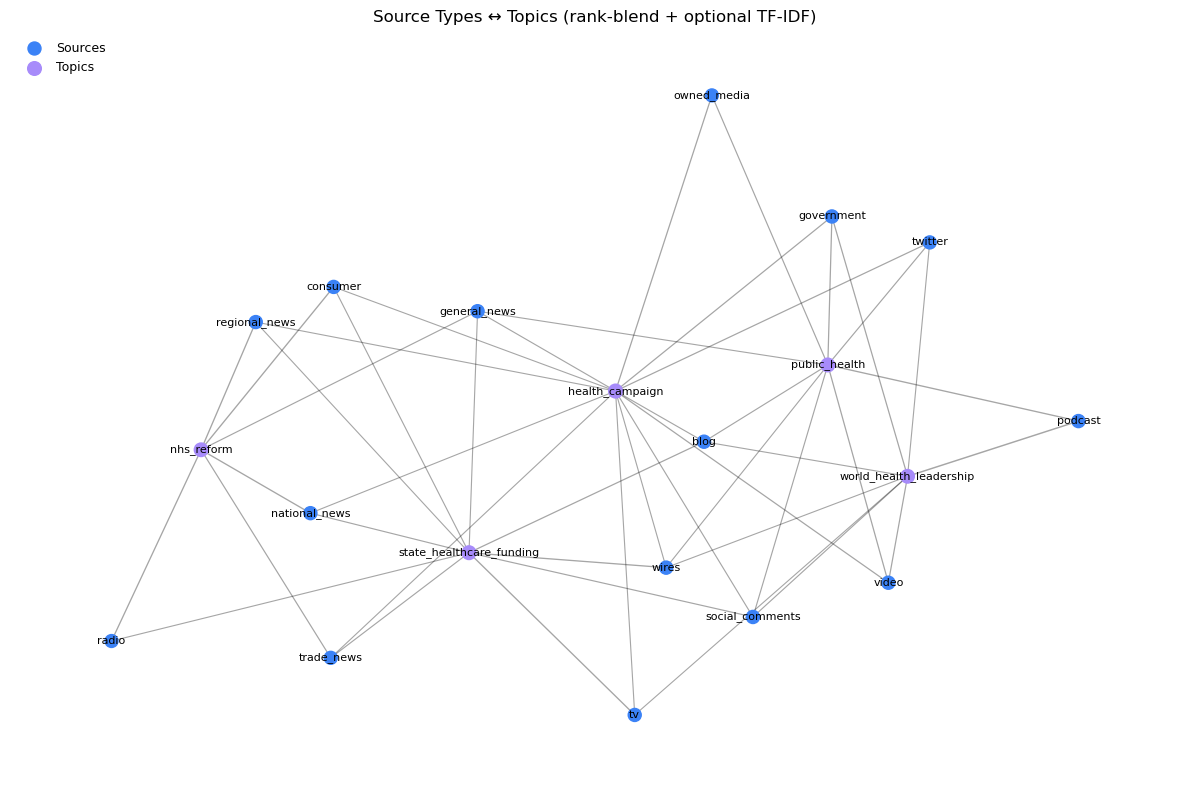

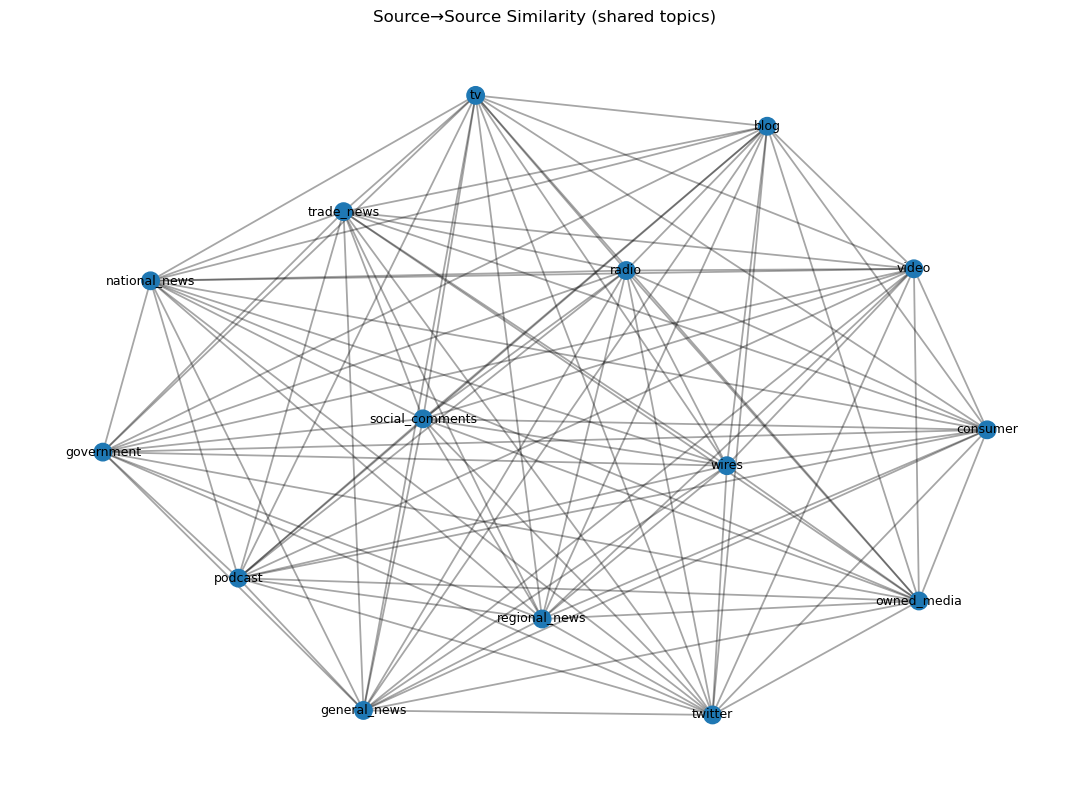

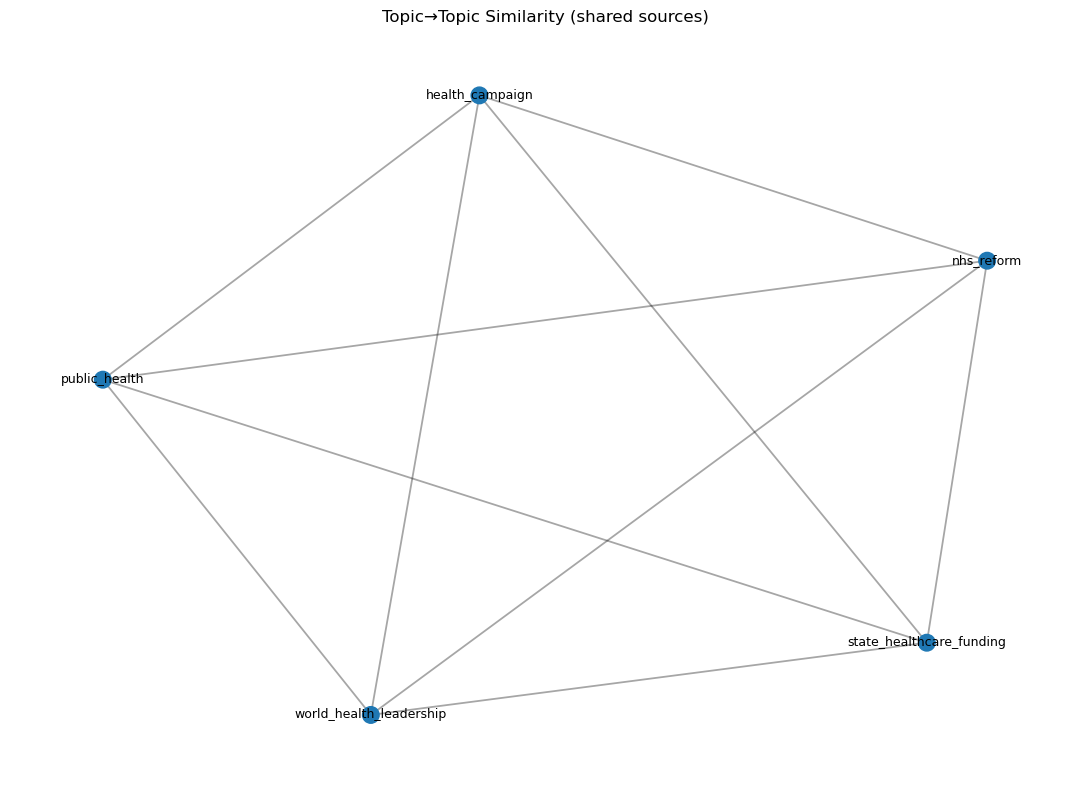

In [23]:
#4) Build + visualize + lists  — robust version with column fallback + clear errors
import numpy as np
import pandas as pd
import networkx as nx
try:
    # only needed if your visualize/project helpers use `nxb.*`
    from networkx.algorithms import bipartite as nxb  # safe if already imported
except Exception:
    pass

# --- Validate columns up front and auto-pick a valid source if needed ---
CANDIDATE_SOURCES = [
    "source_type",       # broad category (safe default in your schema)
    "publication_name",  # outlet
    "publisher_name",
    "source_feed_name",
    "channel_name",
    "feed_name",
]

def _suggest(msg, target, cols):
    from difflib import get_close_matches
    sugg = get_close_matches(target, list(cols), n=3)
    extra = f"\nDid you mean one of: {sugg}" if sugg else ""
    raise KeyError(msg + extra)

# Use the user-provided SOURCE_COL if it exists; otherwise pick the first valid candidate.
if SOURCE_COL not in DF.columns:
    # try to pick a good fallback automatically
    fallback = next((c for c in CANDIDATE_SOURCES if c in DF.columns), None)
    if fallback is None:
        _suggest(f"Missing source column '{SOURCE_COL}' and no fallback found.",
                 SOURCE_COL, DF.columns)
    else:
        print(f"[info] SOURCE_COL '{SOURCE_COL}' not found. Using fallback: '{fallback}'")
        SOURCE_COL = fallback

# Topic must exist (you set TOPIC_COL = 'tag_name' which is present in your schema)
if TOPIC_COL not in DF.columns:
    _suggest(f"Missing topic column '{TOPIC_COL}'.", TOPIC_COL, DF.columns)

# Weight-by columns must all exist
for c in (WEIGHT_BY if isinstance(WEIGHT_BY, list) else [WEIGHT_BY]):
    if c != "count" and c not in DF.columns:
        _suggest(f"Weight column '{c}' not found.", c, DF.columns)

# --- Build
B, agg, sources, topics = build_source_topic_bipartite(
    DF,
    source_col=SOURCE_COL,
    topic_col=TOPIC_COL,
    weight_by=WEIGHT_BY,
    weight_weights=WEIGHT_WEIGHTS,
    min_edge_weight=MIN_EDGE_WEIGHT,
    min_topics_per_source=MIN_TOPICS_PER_SOURCE,
    min_sources_per_topic=MIN_SOURCES_PER_TOPIC,
    use_tfidf=USE_TFIDF,
    use_sum_instead_of_mean=False
)

print("edges kept in agg:", len(agg))
print("sources:", len(sources), "topics:", len(topics))
display(agg.sort_values("weight", ascending=False).head(15))

# --- Auto-relax if everything was pruned
if len(agg) == 0 or len(sources) == 0 or len(topics) == 0:
    print("Nothing left after thresholds → relaxing filters...")
    B, agg, sources, topics = build_source_topic_bipartite(
        DF, SOURCE_COL, TOPIC_COL,
        weight_by=WEIGHT_BY, weight_weights=WEIGHT_WEIGHTS,
        min_edge_weight=0.0, min_topics_per_source=1, min_sources_per_topic=1,
        use_tfidf=False, use_sum_instead_of_mean=False
    )
    print("RELAXED → edges:", len(agg), "sources:", len(sources), "topics:", len(topics))

# --- Visuals
visualize_bipartite(
    B, sources, topics,
    title="Source Types ↔ Topics (rank-blend + optional TF-IDF)",
    label_sources_top=LABEL_SOURCES_TOP,
    label_topics_top=LABEL_TOPICS_TOP,
    edge_keep_pct=EDGE_KEEP_PCT_BIP
)

Gs = project_sources(B, sources, method="overlap")
visualize_projection(Gs, title="Source→Source Similarity (shared topics)", label_top=25, edge_keep_pct=EDGE_KEEP_PCT_PROJ)

Gt = project_topics(B, topics, method="overlap")
visualize_projection(Gt, title="Topic→Topic Similarity (shared sources)", label_top=25, edge_keep_pct=EDGE_KEEP_PCT_PROJ)

In [24]:
edge_table = agg.sort_values("weight", ascending=False).reset_index(drop=True)
display(edge_table.head(25))

,source_type,tag_name,weight
0,podcast,world_health_leadership,0.592232
1,consumer,nhs_reform,0.454511
2,tv,state_healthcare_funding,0.454155
3,regional_news,nhs_reform,0.442323
4,podcast,public_health,0.441619
5,national_news,nhs_reform,0.438460
6,radio,nhs_reform,0.427234
7,wires,state_healthcare_funding,0.414603
8,owned_media,health_campaign,0.376681
9,video,public_health,0.362885


In [25]:
### Top Topic per Source
def top_k_topics_per_source(agg: pd.DataFrame, source_col=SOURCE_COL, topic_col=TOPIC_COL, k=10) -> pd.DataFrame:
    if agg.empty: return agg
    return (agg.sort_values(["weight"], ascending=False)
              .groupby(source_col, group_keys=False)
              .head(k)
              .reset_index(drop=True))

display(top_k_topics_per_source(agg, k=8).head(30))


,source_type,tag_name,weight
0,podcast,world_health_leadership,0.592232
1,consumer,nhs_reform,0.454511
2,tv,state_healthcare_funding,0.454155
3,regional_news,nhs_reform,0.442323
4,podcast,public_health,0.441619
5,national_news,nhs_reform,0.438460
6,radio,nhs_reform,0.427234
7,wires,state_healthcare_funding,0.414603
8,owned_media,health_campaign,0.376681
9,video,public_health,0.362885


In [26]:
### Top Sources per Topic (ranking within each topic)
def top_k_sources_per_topic(agg: pd.DataFrame, source_col=SOURCE_COL, topic_col=TOPIC_COL, k=10) -> pd.DataFrame:
    if agg.empty: return agg
    return (agg.sort_values(["weight"], ascending=False)
              .groupby(topic_col, group_keys=False)
              .head(k)
              .reset_index(drop=True))

display(top_k_sources_per_topic(agg, k=8).head(30))

,source_type,tag_name,weight
0,podcast,world_health_leadership,0.592232
1,consumer,nhs_reform,0.454511
2,tv,state_healthcare_funding,0.454155
3,regional_news,nhs_reform,0.442323
4,podcast,public_health,0.441619
5,national_news,nhs_reform,0.438460
6,radio,nhs_reform,0.427234
7,wires,state_healthcare_funding,0.414603
8,owned_media,health_campaign,0.376681
9,video,public_health,0.362885


In [27]:
# Strength tables (weighted degree)
def _node_strength(G):
    return {n: sum(G[n][nbr].get("weight",1) for nbr in G.neighbors(n)) for n in G.nodes()}
if B.number_of_nodes() > 0:
    S = _node_strength(B)
    display(pd.Series({n:s for n,s in S.items() if n in sources}, name="strength")
              .sort_values(ascending=False).head(25).to_frame())
    display(pd.Series({n:s for n,s in S.items() if n in topics},  name="strength")
              .sort_values(ascending=False).head(25).to_frame())

,strength
consumer,1.302577
national_news,1.298073
regional_news,1.292732
radio,1.285449
trade_news,1.248743
general_news,1.222063
tv,1.135707
wires,1.128474
blog,1.116339
social_comments,1.107949


,strength
public_health,4.011835
world_health_leadership,3.859053
health_campaign,3.802268
state_healthcare_funding,3.448491
nhs_reform,2.361631


In [28]:
### Source -> Source (From Visual Above)
pairs_src = (pd.DataFrame([(u, v, d.get("weight", 1)) for u, v, d in Gs.edges(data=True)],
                          columns=["source_u", "source_v", "weight"])
               .sort_values("weight", ascending=False))
display(pairs_src.head(25))

,source_u,source_v,weight
0,blog,consumer,1.0
53,video,radio,1.0
77,general_news,radio,1.0
76,owned_media,twitter,1.0
75,owned_media,government,1.0
74,owned_media,tv,1.0
73,owned_media,social_comments,1.0
72,owned_media,wires,1.0
71,owned_media,regional_news,1.0
70,owned_media,radio,1.0


In [29]:
### Topic -> Topic (From Visual)
pairs_topic = (pd.DataFrame([(u, v, d.get("weight", 1)) for u, v, d in Gt.edges(data=True)],
                            columns=["topic_u", "topic_v", "weight"])
                 .sort_values("weight", ascending=False))
display(pairs_topic.head(25))

,topic_u,topic_v,weight
0,health_campaign,state_healthcare_funding,1.0
1,health_campaign,nhs_reform,1.0
2,health_campaign,public_health,1.0
3,health_campaign,world_health_leadership,1.0
4,state_healthcare_funding,nhs_reform,1.0
5,state_healthcare_funding,public_health,1.0
6,state_healthcare_funding,world_health_leadership,1.0
7,world_health_leadership,nhs_reform,1.0
8,world_health_leadership,public_health,1.0
9,public_health,nhs_reform,1.0


In [ ]:
# === Influence Network: concise static plot (uses df_conv) ====================
# What this does (brief):
# - Takes your unified attribution table (df_conv) with columns:
#   kind, dimension, value, credit, credit_share, rating, rating_pct
# - Builds a directed graph: state/value  ->  <CONV> (edge weight = credit_share or credit)
# - Plots a concise static network:
#     color = dimension, shape = kind (● item, ▲ term),
#     node size ≈ credit_share, edge width ≈ weight,
#     labels only for nodes above a threshold to avoid clutter.

In [ ]:
SINK_LABEL = "<CONV>"
DIMENSION_COLORS = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
]
KIND_MARKERS = {"item": "o", "term": "^"}  # circle, triangle

# ---- prep & helpers ----
def prep_attr_df_conv(df_conv: pd.DataFrame) -> pd.DataFrame:
    required = {"kind","dimension","value","credit","credit_share","rating","rating_pct"}
    missing = required - set(df_conv.columns)
    if missing:
        raise ValueError(f"df_conv missing required columns: {sorted(missing)}")
    out = df_conv.copy()
    out["kind"] = out["kind"].astype(str)
    out["dimension"] = out["dimension"].astype(str)
    out["value"] = out["value"].astype(str)
    for c in ("credit","credit_share","rating_pct"):
        out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0.0)
    out["rating"] = pd.to_numeric(out["rating"], errors="coerce").fillna(0).astype(int)
    return out

def filter_top_per_dimension(df_conv: pd.DataFrame, top_k: Optional[int] = 50, min_share: float = 0.0) -> pd.DataFrame:
    x = df_conv.copy()
    # filter by per-dimension share (credit_share) — classic behavior
    if min_share > 0:
        x = x[x["credit_share"] >= min_share]
    if top_k and top_k > 0:
        x = (
            x.sort_values(["dimension","credit_share"], ascending=[True, False])
             .groupby("dimension", as_index=False)
             .head(top_k)
        )
    return x.reset_index(drop=True)

def choose_labels_by_rank(G: nx.DiGraph, top_labels_per_dim: int = 10) -> dict:
    # rank by per-dimension credit_share stored on nodes
    by_dim = {}
    for n, d in G.nodes(data=True):
        if n == SINK_LABEL: 
            continue
        dim = d.get("dimension","other")
        by_dim.setdefault(dim, []).append((n, d.get("credit_share", 0.0)))
    labels = {}
    for dim, pairs in by_dim.items():
        pairs.sort(key=lambda t: t[1], reverse=True)
        for n,_ in pairs[:top_labels_per_dim]:
            labels[n] = n
    return labels

In [41]:
# -------------------- Attribution prep shim (drop-in) --------------------
import numpy as np
import pandas as pd

# ---- constants used by your plotting code
SINK_LABEL = "<CONV>"
DIMENSION_COLORS = [
    "#3b82f6", "#a78bfa", "#f59e0b", "#10b981", "#ef4444", "#8b5cf6",
    "#14b8a6", "#eab308", "#f97316", "#22c55e", "#ec4899", "#06b6d4"
]
KIND_MARKERS = {"item": "o", "term": "^", "sink": "s"}

def prep_attr_df_conv(df_conv: pd.DataFrame) -> pd.DataFrame:
    """
    Build the columns expected by build_graph_classic/draw_static_classic from your current df_conv.
    Assumptions (tweak as needed):
      - value := tag_name
      - dimension := 'person' if has_person else 'topic'
      - kind := 'item' for person-like values, 'term' otherwise
      - credit := vipr_weight for rows where is_conversion is True, else 0
      - credit_share := credit / sum(credit)
      - rating := rank-based 1..5 buckets from per-value conversion counts
      - rating_pct := per-value conversion count percentile [0,1]
    """
    required_source = {
        "tag_name", "has_person", "is_conversion", "vipr_weight"
    }
    missing_src = [c for c in required_source if c not in df_conv.columns]
    if missing_src:
        raise ValueError(
            f"prep_attr_df_conv needs these columns present first: {sorted(missing_src)}"
        )

    out = df_conv.copy()

    # 1) value / dimension / kind
    out["value"] = out["tag_name"].astype("string")

    out["dimension"] = pd.Series(
        np.where(out["has_person"].astype(bool), "person", "topic"),
        index=out.index,
        dtype="string"
    )

    out["kind"] = pd.Series(
        np.where(out["dimension"].eq("person"), "item", "term"),
        index=out.index,
        dtype="string"
    )

    # 2) credit (simple, interpretable): credit only on conversions, weighted by vipr_weight
    #    You can strengthen with circulation/sentiment if you like (see commented line).
    conv = out["is_conversion"].astype(bool)
    vw = pd.to_numeric(out["vipr_weight"], errors="coerce").fillna(0).clip(lower=0)
    out["credit"] = np.where(conv, vw, 0.0).astype(float)

    # Example alternative with circulation & sentiment amplification:
    # circ = pd.to_numeric(out["circulation_size"], errors="coerce").fillna(0)
    # sent = pd.to_numeric(out["sentiment_score"], errors="coerce").fillna(0)
    # out["credit"] = np.where(conv, (vw + 1.0) * (1.0 + np.log1p(circ)) * (1.0 + (sent > 0)), 0.0)

    # 3) credit_share by value
    grp_credit = out.groupby("value")["credit"].sum().rename("credit_sum")
    out = out.join(grp_credit, on="value")
    total_credit = float(grp_credit.sum())
    if total_credit <= 0:
        # guard: avoid divide-by-zero — give tiny uniform share to make the chart render
        nvals = grp_credit.shape[0] if grp_credit.shape[0] > 0 else 1
        out["credit_share"] = 1.0 / nvals
    else:
        out["credit_share"] = out["credit_sum"] / total_credit

    # 4) rating / rating_pct based on conversion counts per value
    conv_counts = out.groupby("value")["is_conversion"].sum().rename("conv_count")
    out = out.join(conv_counts, on="value")
    # Percentile rank [0,1]
    out["rating_pct"] = out["conv_count"].rank(pct=True).astype(float)
    # Map to 1..5 buckets (quintiles)
    out["rating"] = np.ceil(out["rating_pct"] * 5).clip(1, 5).astype(int)

    # Keep only what the graph builder expects + keys it groups by
    needed = [
        "value", "kind", "dimension",
        "credit", "credit_share",
        "rating", "rating_pct"
    ]
    return out[needed].copy()

def filter_top_per_dimension(attr_df: pd.DataFrame, top_k=50, min_share: float = 0.0) -> pd.DataFrame:
    """
    Keep top_k by credit_share within each dimension, and drop anything below min_share.
    """
    df = attr_df.copy()
    if min_share > 0:
        df = df[df["credit_share"] >= float(min_share)]
    # rank within dimension
    df["_r"] = df.groupby("dimension")["credit_share"].rank(method="first", ascending=False)
    return df[df["_r"] <= int(top_k)].drop(columns="_r")

def choose_labels_by_rank(G: "nx.Graph", top_labels_per_dim: int = 10) -> dict:
    """
    Choose label set: top-N per dimension by credit_share stored on nodes.
    """
    # pull node attributes to a DataFrame for ranking
    rows = []
    for n, d in G.nodes(data=True):
        if n == SINK_LABEL:
            continue
        rows.append({"node": n,
                     "dimension": d.get("dimension", "other"),
                     "credit_share": float(d.get("credit_share", 0.0))})
    if not rows:
        return {}
    tmp = pd.DataFrame(rows)
    tmp["_r"] = tmp.groupby("dimension")["credit_share"].rank(method="first", ascending=False)
    keep = set(tmp[tmp["_r"] <= int(top_labels_per_dim)]["node"].tolist())
    return {n: n for n in keep}
# -------------------- end shim --------------------

edges kept in agg: 62
sources: 15 topics: 5


,source_type,tag_name,weight
28,podcast,world_health_leadership,0.592232
5,consumer,nhs_reform,0.454511
52,tv,state_healthcare_funding,0.454155
36,regional_news,nhs_reform,0.442323
27,podcast,public_health,0.441619
19,national_news,nhs_reform,0.438460
31,radio,nhs_reform,0.427234
63,wires,state_healthcare_funding,0.414603
23,owned_media,health_campaign,0.376681
59,video,public_health,0.362885


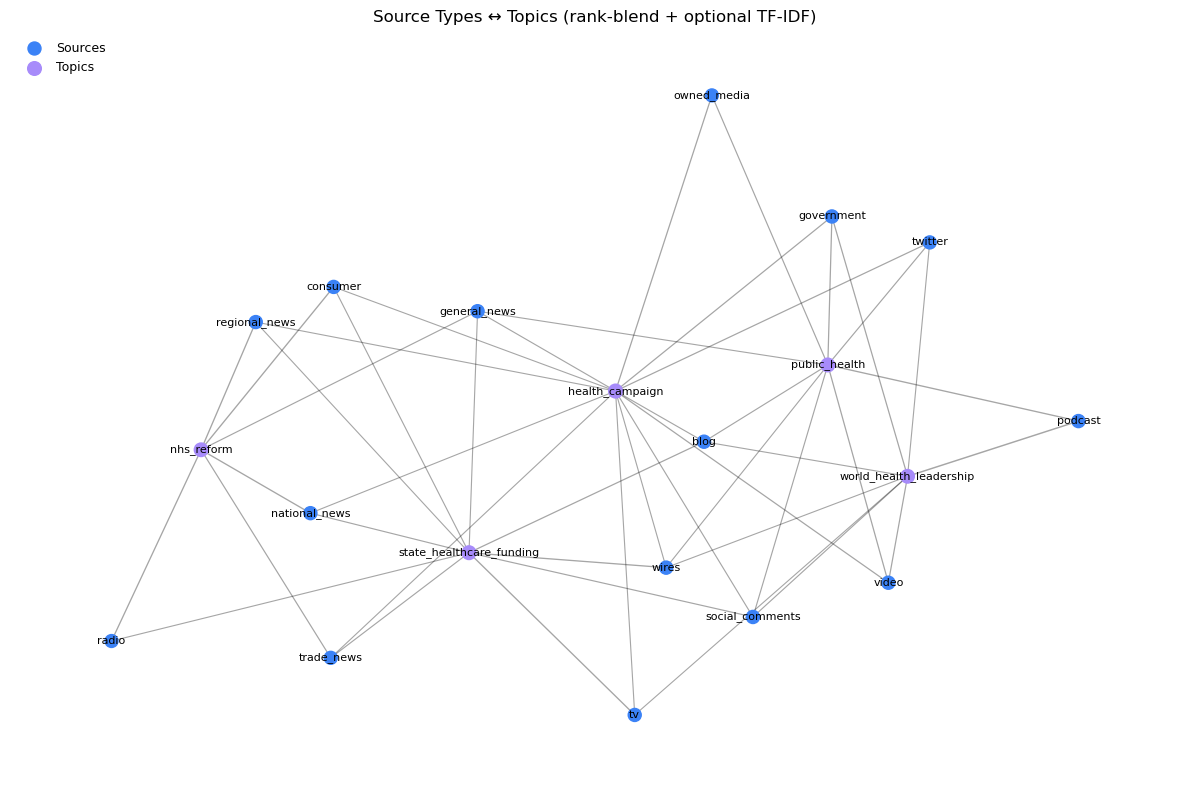

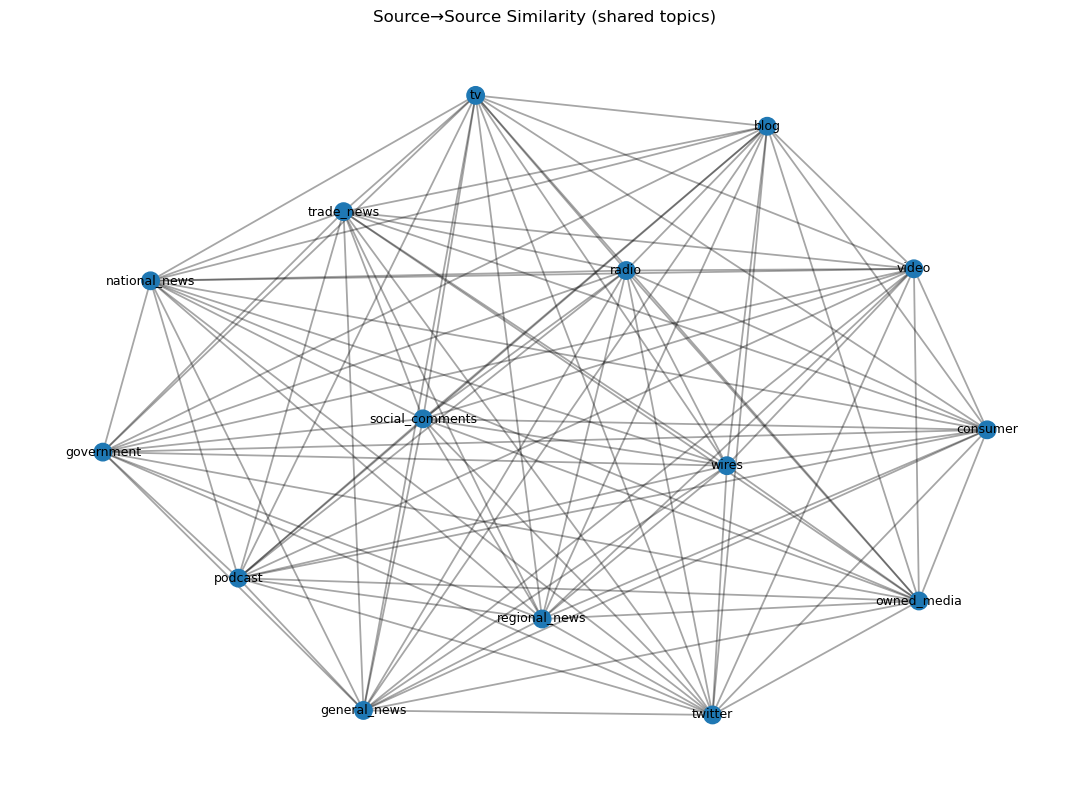

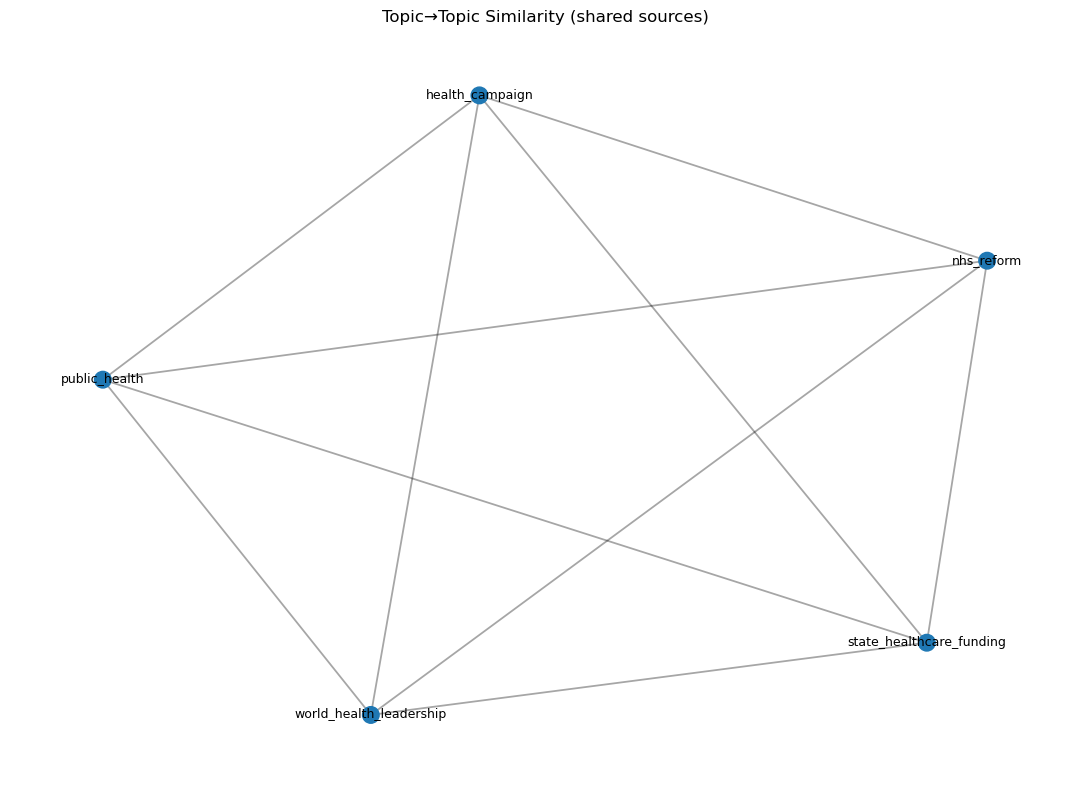

In [44]:
# --- CONFIG (choose ONE source column that exists) ---
SOURCE_COL = "source_type"          # or: "publication_name", "publisher_name", "source_feed_name", "channel_name", "feed_name"
TOPIC_COL  = "tag_name"

WEIGHT_BY = ["circulation_size", "vipr_weight", "hit_strength"]
WEIGHT_WEIGHTS = None
MIN_EDGE_WEIGHT = 0.2
MIN_TOPICS_PER_SOURCE = 2
MIN_SOURCES_PER_TOPIC = 2
USE_TFIDF = True

EDGE_KEEP_PCT_BIP  = 75
EDGE_KEEP_PCT_PROJ = 70
LABEL_SOURCES_TOP  = 25
LABEL_TOPICS_TOP   = 8

# --- Sanity checks + fallback if SOURCE_COL mistyped ---
from difflib import get_close_matches
CANDIDATE_SOURCES = ["source_type","publication_name","publisher_name","source_feed_name","channel_name","feed_name"]
if SOURCE_COL not in df_conv.columns:
    fb = next((c for c in CANDIDATE_SOURCES if c in df_conv.columns), None)
    if fb is None:
        raise KeyError(f"Bad SOURCE_COL='{SOURCE_COL}'. Did you mean: {get_close_matches(SOURCE_COL, df_conv.columns.tolist(), n=3)}")
    print(f"[info] SOURCE_COL '{SOURCE_COL}' not found → using '{fb}'")
    SOURCE_COL = fb
if TOPIC_COL not in df_conv.columns:
    raise KeyError(f"Bad TOPIC_COL='{TOPIC_COL}'. Did you mean: {get_close_matches(TOPIC_COL, df_conv.columns.tolist(), n=3)}")

# --- Build ---
B, agg, sources, topics = build_source_topic_bipartite(
    df_conv,
    source_col=SOURCE_COL,
    topic_col=TOPIC_COL,
    weight_by=WEIGHT_BY,
    weight_weights=WEIGHT_WEIGHTS,
    min_edge_weight=MIN_EDGE_WEIGHT,
    min_topics_per_source=MIN_TOPICS_PER_SOURCE,
    min_sources_per_topic=MIN_SOURCES_PER_TOPIC,
    use_tfidf=USE_TFIDF,
    use_sum_instead_of_mean=False
)
print("edges kept in agg:", len(agg))
print("sources:", len(sources), "topics:", len(topics))
display(agg.sort_values("weight", ascending=False).head(15))

# --- Relax if pruned away ---
if len(agg)==0 or len(sources)==0 or len(topics)==0:
    print("Nothing left after thresholds → relaxing filters…")
    B, agg, sources, topics = build_source_topic_bipartite(
        df_conv, SOURCE_COL, TOPIC_COL,
        weight_by=WEIGHT_BY, weight_weights=WEIGHT_WEIGHTS,
        min_edge_weight=0.0, min_topics_per_source=1, min_sources_per_topic=1,
        use_tfidf=False, use_sum_instead_of_mean=False
    )
    print("RELAXED → edges:", len(agg), "sources:", len(sources), "topics:", len(topics))

# --- Visuals ---
visualize_bipartite(
    B, sources, topics,
    title="Source Types ↔ Topics (rank-blend + optional TF-IDF)",
    label_sources_top=LABEL_SOURCES_TOP,
    label_topics_top=LABEL_TOPICS_TOP,
    edge_keep_pct=EDGE_KEEP_PCT_BIP
)

Gs = project_sources(B, sources, method="overlap")
visualize_projection(Gs, title="Source→Source Similarity (shared topics)", label_top=25, edge_keep_pct=EDGE_KEEP_PCT_PROJ)

Gt = project_topics(B, topics, method="overlap")
visualize_projection(Gt, title="Topic→Topic Similarity (shared sources)", label_top=25, edge_keep_pct=EDGE_KEEP_PCT_PROJ)

In [52]:
# ===========================
# TABLE COMPARISON (TERMS) — robust to raw or prepped input
# ===========================
import numpy as np
import pandas as pd

# ---- Standardize to the columns we need for terms tables
def _ensure_attr_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Accepts either raw df_conv (with tag_name, has_person, is_conversion, vipr_weight)
    or an already-prepped attribution table (with value, kind, credit, credit_share).
    Returns a DataFrame with at least: ['value','kind','credit','credit_share'].
    """
    needed = {"value","kind","credit","credit_share"}
    if needed.issubset(df.columns):
        out = df.copy()
        # Coerce numeric types safely
        out["credit"] = pd.to_numeric(out["credit"], errors="coerce").fillna(0.0)
        out["credit_share"] = pd.to_numeric(out["credit_share"], errors="coerce").fillna(0.0)
        out["value"] = out["value"].astype(str)
        out["kind"] = out["kind"].astype(str)
        return out

    # Otherwise we assume RAW df_conv with these columns:
    required_raw = {"tag_name","has_person","is_conversion","vipr_weight"}
    missing = [c for c in required_raw if c not in df.columns]
    if missing:
        raise KeyError(f"Input is missing required columns for raw mode: {missing}")

    out = df.copy()

    # value := topic string (adjust to publication_name, etc. if you want a different unit)
    out["value"] = out["tag_name"].astype(str)

    # kind := 'item' for person-like rows, 'term' otherwise (consistent with your graph viz legend)
    # note: we only use this to filter terms; you can refine later if needed
    out["kind"] = np.where(out["has_person"].astype(bool), "item", "term").astype(str)

    # credit := basic, interpretable: weight only on conversion rows
    vw = pd.to_numeric(out["vipr_weight"], errors="coerce").fillna(0).clip(lower=0).astype(float)
    conv = out["is_conversion"].astype(bool)
    out["credit"] = np.where(conv, vw, 0.0)

    # credit_share := per-value share within the current chunk (your current table design)
    credit_by_value = out.groupby("value")["credit"].sum().rename("credit_sum")
    out = out.join(credit_by_value, on="value")
    total_credit = float(credit_by_value.sum())
    if total_credit <= 0:
        # If there are no conversions/credit at all, give tiny uniform shares so tables render
        n = max(len(credit_by_value), 1)
        out["credit_share"] = 1.0 / n
    else:
        out["credit_share"] = out["credit_sum"] / total_credit

    return out[["value","kind","credit","credit_share"]].copy()


def prep_terms_for_table(df_in: pd.DataFrame) -> pd.DataFrame:
    out = _ensure_attr_columns(df_in)
    # keep only 'term' rows; if none exist, fall back to all to avoid empty tables
    terms = out[out["kind"] == "term"].copy()
    if terms.empty:
        # optional: warn or just return all
        terms = out.copy()
    return terms


def add_global_term_share(df_conv_terms: pd.DataFrame) -> pd.DataFrame:
    total = float(df_conv_terms["credit"].sum())
    df2 = df_conv_terms.copy()
    if total > 0:
        df2["credit_share_global"] = df2["credit"] / total
    else:
        # avoid division by zero; uniform fallback
        n = max(len(df2), 1)
        df2["credit_share_global"] = 1.0 / n
    return df2


def top_terms(df_conv_terms: pd.DataFrame, field: str, n: int = 20) -> pd.DataFrame:
    tbl = (df_conv_terms.groupby("value", as_index=False)[field]
                        .sum()
                        .sort_values(field, ascending=False)
                        .head(n))
    tbl.insert(0, "rank", range(1, len(tbl) + 1))
    return tbl


# ===== Run =====
_terms = prep_terms_for_table(df_conv)         # works with raw or prepped
_terms = add_global_term_share(_terms)

top_chunk  = top_terms(_terms, "credit_share", n=20).rename(columns={
    "rank":"rank_chunk", "credit_share":"credit_share_chunk"
})
top_global = top_terms(_terms, "credit_share_global", n=20).rename(columns={
    "rank":"rank_global", "credit_share_global":"credit_share_global"
})

# Merge to compare ranks & values; keep union of top-20 in each mode
compare = pd.merge(top_chunk, top_global, on="value", how="outer")

# Fill missing ranks/shares for union rows
max_rank = 999
compare["rank_chunk"]  = compare["rank_chunk"].fillna(max_rank).astype(int)
compare["rank_global"] = compare["rank_global"].fillna(max_rank).astype(int)
compare["credit_share_chunk"]  = compare["credit_share_chunk"].fillna(0.0)
compare["credit_share_global"] = compare["credit_share_global"].fillna(0.0)

# Rank change (negative = moved up globally)
compare["rank_delta"]  = compare["rank_global"] - compare["rank_chunk"]
compare["share_delta"] = compare["credit_share_global"] - compare["credit_share_chunk"]

# Nice sort: best global rank first, then chunk rank
compare = compare.sort_values(["rank_global", "rank_chunk"]).reset_index(drop=True)

print("Top 20 Terms — CHUNK-normalized")
display(top_chunk)

print("Top 20 Terms — GLOBAL-normalized")
display(top_global)

print("Comparison (union of Top 20s) — rank/weight changes")
display(compare[
    ["value", "rank_chunk", "rank_global", "rank_delta",
     "credit_share_chunk", "credit_share_global", "share_delta"]
])

Top 20 Terms — CHUNK-normalized


,rank_chunk,value,credit_share_chunk
3,1,public_health,77765.108749
0,2,health_campaign,152.866114
5,3,world_health_leadership,30.308619
4,4,state_healthcare_funding,0.164737
2,5,nhs_reform,0.002274
1,6,last_smoke_campaign,0.000013


Top 20 Terms — GLOBAL-normalized


,rank_global,value,credit_share_global
3,1,public_health,0.935914
0,2,health_campaign,0.044776
5,3,world_health_leadership,0.017693
4,4,state_healthcare_funding,0.001420
2,5,nhs_reform,0.000189
1,6,last_smoke_campaign,0.000007


Comparison (union of Top 20s) — rank/weight changes


,value,rank_chunk,rank_global,rank_delta,credit_share_chunk,credit_share_global,share_delta
0,public_health,1,1,0,77765.108749,0.935914,-77764.172834
1,health_campaign,2,2,0,152.866114,0.044776,-152.821338
2,world_health_leadership,3,3,0,30.308619,0.017693,-30.290926
3,state_healthcare_funding,4,4,0,0.164737,0.001420,-0.163317
4,nhs_reform,5,5,0,0.002274,0.000189,-0.002084
5,last_smoke_campaign,6,6,0,0.000013,0.000007,-0.000007


In [ ]:
# ============================================================
# Publisher ↔ Term Content Network 
# ------------------------------------------------------------
# What this does (brief):
# - Builds a bipartite graph between publishers and their
#   articles' most influential term.
# - "Most influential term" per article is the matched term
#   whose global credit_share (from df_conv where kind=='term')
#   is highest among terms present in the article text.
# - Node size:
#     • publisher: number of matched articles (degree, weighted)
#     • term: total matched weight across publishers
# - Edge weight: sum of matched term weights between that
#   publisher and term (stronger association = thicker edge)
# - Visual: circles (publishers), triangles (terms), spring layout,
#   labels for top-N per type to keep it readable.

In [56]:
# --- keep this ---
_ensure_cols_present(df_conv, ["publisher_name","headline","article_body"], "df_conv")

# --- NEW: build term scores from either RAW or PREPPED df_conv ---
import re
import numpy as np
import pandas as pd

def build_term_scores(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns a DataFrame with columns: ['term','term_weight'].
    Works with:
      A) PREPPED input having ['value','kind','credit','credit_share']
      B) RAW input having   ['tag_name','has_person','is_conversion','vipr_weight']
    """
    # Mode A: prepped table present
    if {"value","kind","credit","credit_share"}.issubset(df.columns):
        terms = df.loc[df["kind"] == "term", ["value","credit","credit_share"]].copy()
        if terms.empty:
            # fallback: if no 'term' rows, treat all as terms
            terms = df[["value","credit","credit_share"]].copy()
        # Prefer global weight from credit; fallback to aggregated share if needed
        credit_by_term = terms.groupby("value", as_index=False)["credit"].sum().rename(columns={"value":"term","credit":"credit_sum"})
        total_credit = float(credit_by_term["credit_sum"].sum())
        if total_credit > 0:
            credit_by_term["term_weight"] = credit_by_term["credit_sum"] / total_credit
            return credit_by_term[["term","term_weight"]].sort_values("term_weight", ascending=False).reset_index(drop=True)
        # fallback to share aggregation if credit is all zeros
        share_by_term = terms.groupby("value", as_index=False)["credit_share"].sum().rename(columns={"value":"term","credit_share":"term_weight"})
        return share_by_term.sort_values("term_weight", ascending=False).reset_index(drop=True)

    # Mode B: raw table → derive value/kind/credit, then normalize globally
    required_raw = {"tag_name","has_person","is_conversion","vipr_weight"}
    missing = [c for c in required_raw if c not in df.columns]
    if missing:
        raise ValueError(f"df_conv missing required columns for raw mode: {missing}")

    tmp = df.copy()
    tmp["value"] = tmp["tag_name"].astype(str)
    tmp["kind"]  = np.where(tmp["has_person"].astype(bool), "item", "term")
    vw = pd.to_numeric(tmp["vipr_weight"], errors="coerce").fillna(0).clip(lower=0).astype(float)
    tmp["credit"] = np.where(tmp["is_conversion"].astype(bool), vw, 0.0)

    credit_by_term = (tmp.loc[tmp["kind"]=="term"]
                         .groupby("value", as_index=False)["credit"].sum()
                         .rename(columns={"value":"term","credit":"credit_sum"}))
    if credit_by_term.empty:
        # If nothing marked as 'term', compute over all values
        credit_by_term = (tmp.groupby("value", as_index=False)["credit"].sum()
                             .rename(columns={"value":"term","credit":"credit_sum"}))
    total_credit = float(credit_by_term["credit_sum"].sum())
    if total_credit <= 0:
        # uniform fallback so downstream code still runs
        n = max(len(credit_by_term), 1)
        credit_by_term["term_weight"] = 1.0 / n
    else:
        credit_by_term["term_weight"] = credit_by_term["credit_sum"] / total_credit
    return credit_by_term[["term","term_weight"]].sort_values("term_weight", ascending=False).reset_index(drop=True)

# ---- Build ranked terms
term_scores = build_term_scores(df_conv)  # <- works for raw or prepped
ranked_terms = list(term_scores[["term","term_weight"]].itertuples(index=False, name=None))

# --------- Finder: best (term, weight) present in a text ----------
def compile_term_patterns(terms):
    # whole-word-ish match, case-insensitive; escape special chars
    return [re.compile(rf"\b{re.escape(t)}\b", flags=re.IGNORECASE) for t in terms]

def best_term_for_text(text, ranked_terms, patterns):
    """Return (best_term, best_weight) present in 'text' or (None, 0.0).
       ranked_terms: list of (term, weight), sorted desc by weight
       patterns:     list of compiled regex, aligned 1:1 with ranked_terms
    """
    for (t, w), pat in zip(ranked_terms, patterns):
        if pat.search(text):
            return t, float(w)
    return None, 0.0

# Compile patterns (optionally cap to top-N for speed, e.g., top 500)
TOP_N = 500
patterns = compile_term_patterns(term_scores["term"].head(TOP_N).tolist())
ranked_terms_top = ranked_terms[:TOP_N]

In [59]:
# --------- Build edges: publisher ↔ best_term ----------
def build_publisher_term_edges(
    articles: pd.DataFrame,
    term_table: pd.DataFrame,
    term_limit: int = 500,
    min_term_weight: float = 0.0
) -> pd.DataFrame:
    """
    Returns edge table with columns: publisher, term, weight
    weight = sum of best_term weight across that publisher's matched articles.
    Only matches among top 'term_limit' terms by weight are considered for speed.
    """
    tt = term_table.head(term_limit).copy()
    ranked_terms = list(tt.itertuples(index=False, name=None))  # (term, weight)
    patterns = compile_term_patterns([t for t,_ in ranked_terms])

    edges = {}
    for _, r in articles.iterrows():
        txt = f"{r['headline']} {r['article_body']}"
        best_t, best_w = best_term_for_text(txt, ranked_terms, patterns)
        if best_t is None or best_w < min_term_weight:
            continue
        key = (r["publisher_name"], best_t)
        edges[key] = edges.get(key, 0.0) + best_w

    if not edges:
        return pd.DataFrame(columns=["publisher","term","weight"])

    pub, term, w = zip(*[(p,t,v) for (p,t),v in edges.items()])
    return pd.DataFrame({"publisher": pub, "term": term, "weight": w})

# --------- Graph builder & plotter ----------
def build_bipartite_graph(edges: pd.DataFrame) -> nx.Graph:
    """
    Build an undirected bipartite graph:
      set A = publishers (type='publisher')
      set B = terms      (type='term')
    Edge weights = aggregated association strength.
    """
    G = nx.Graph()
    for _, r in edges.iterrows():
        p, t, w = r["publisher"], r["term"], float(r["weight"])
        if p not in G: G.add_node(p, ntype="publisher")
        if t not in G: G.add_node(t, ntype="term")
        if w > 0:
            G.add_edge(p, t, weight=w)
    return G

def draw_publisher_term_network(
    G: nx.Graph,
    top_labels_per_type: int = 12,
    figsize=(14, 9)
):
    # size nodes by (weighted) degree
    def node_strength(n):
        return sum(G[n][nbr].get("weight", 0.0) for nbr in G.neighbors(n))

    strengths = {n: node_strength(n) for n in G.nodes()}
    max_strength = max(strengths.values()) if strengths else 1.0

    # scale sizes (nonlinear to spread)
    def scale(s): return max(80.0, (s / max_strength) ** 0.65 * 3000.0)
    sizes = [scale(strengths[n]) for n in G.nodes()]

    # colors & shapes by type
    color_map = {"publisher": "#1f77b4", "term": "#ff7f0e"}
    shape_map = {"publisher": "o", "term": "^"}
    node_types = nx.get_node_attributes(G, "ntype")
    node_colors = [color_map.get(node_types.get(n, "publisher"), "#7f7f7f") for n in G.nodes()]

    # layout (weighted for clarity)
    pos = nx.spring_layout(G, k=0.6, seed=42, weight="weight")

    plt.figure(figsize=figsize)

    # edges: thickness by weight (sqrt for contrast)
    widths = [max(0.5, (G[u][v].get("weight", 0.0) ** 0.5) * 6) for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.25)

    # draw nodes by type (for shapes)
    for t, marker in shape_map.items():
        nodes_t = [n for n in G.nodes() if node_types.get(n) == t]
        sizes_t = [sizes[list(G.nodes()).index(n)] for n in nodes_t]
        colors_t = [node_colors[list(G.nodes()).index(n)] for n in nodes_t]
        nx.draw_networkx_nodes(
            G, pos, nodelist=nodes_t, node_size=sizes_t, node_color=colors_t,
            node_shape=marker, linewidths=0.8, edgecolors="#333", alpha=0.95
        )

    # labels: top-N publishers and top-N terms by strength
    pubs = [n for n in G.nodes() if node_types.get(n) == "publisher"]
    terms = [n for n in G.nodes() if node_types.get(n) == "term"]
    pubs_top = sorted(pubs, key=lambda n: strengths[n], reverse=True)[:top_labels_per_type]
    terms_top = sorted(terms, key=lambda n: strengths[n], reverse=True)[:top_labels_per_type]
    labels = {n: n for n in pubs_top + terms_top}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

    # title + legend
    plt.title("Content Network: Publishers ↔ Highest-Impact Terms (per article)", fontsize=14, pad=10)
    subtitle = "Circle = publisher • Triangle = term • Node size ≈ weighted degree • Edge width ≈ association strength"
    plt.suptitle(subtitle, y=0.80, fontsize=9, color="#444")

    legend_handles = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=color_map["publisher"],
               markeredgecolor='#333', label='publisher', markersize=8),
        Line2D([0],[0], marker='^', color='w', markerfacecolor=color_map["term"],
               markeredgecolor='#333', label='term', markersize=8),
    ]
    plt.legend(handles=legend_handles, loc='upper left', frameon=True, title='Node type')

    plt.axis("off")
    plt.tight_layout()
    plt.show()

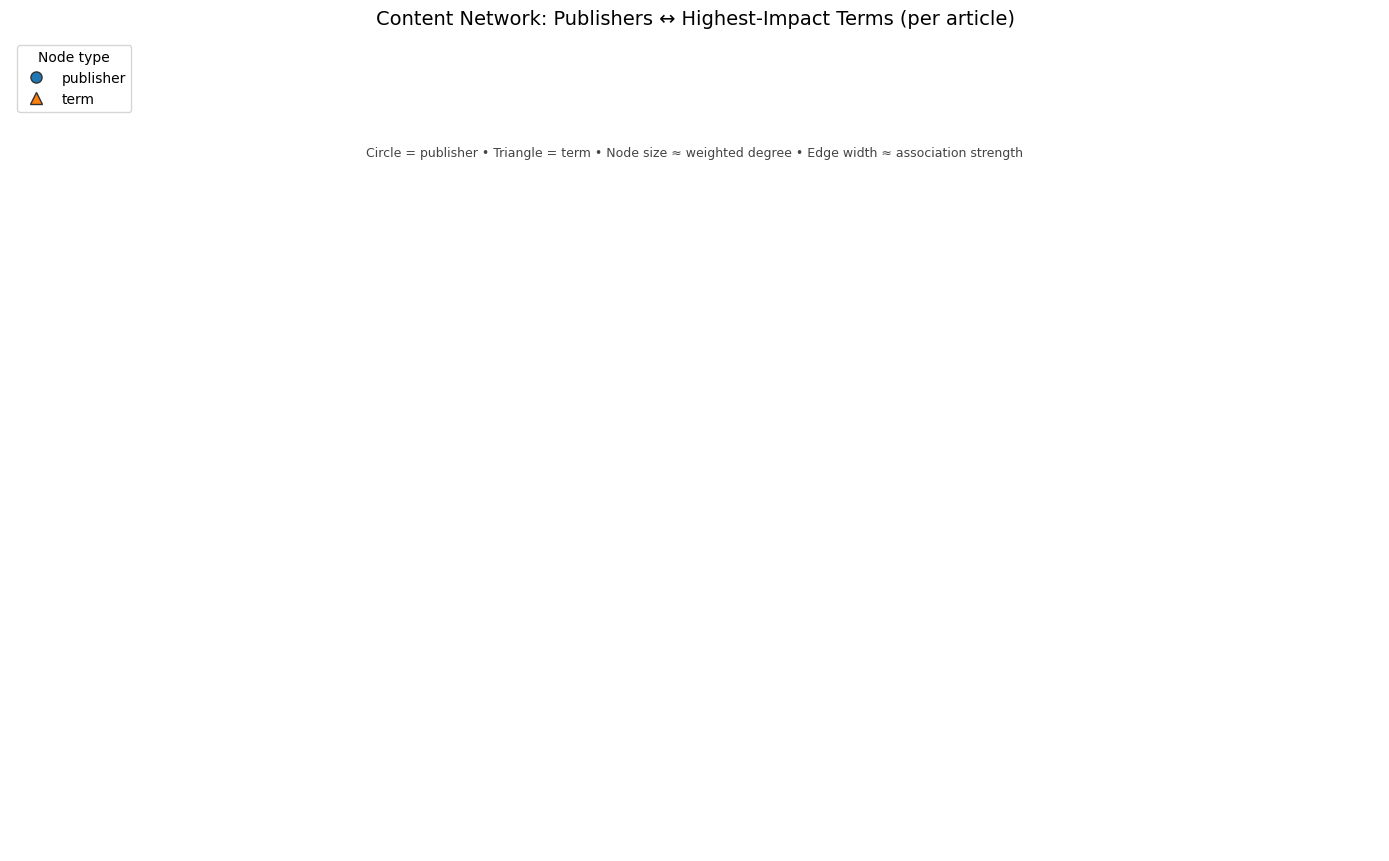

,Publisher,Term,AssocWeight


In [60]:
TERM_LIMIT = 200          # only match among the top-N terms by global weight (speed + precision)
MIN_TERM_WEIGHT = 0.0     # ignore terms whose global weight is below this
TOP_LABELS_PER_TYPE = 12  # labels per node type in the plot

# --------------------------
# RUN
# --------------------------
edges = build_publisher_term_edges(
    articles=df_conv,
    term_table=term_scores,
    term_limit=TERM_LIMIT,
    min_term_weight=MIN_TERM_WEIGHT
)

G_content = build_bipartite_graph(edges)
draw_publisher_term_network(G_content, top_labels_per_type=TOP_LABELS_PER_TYPE, figsize=(14, 9))

# Optional quick table to inspect top associations
display(
    edges.sort_values("weight", ascending=False)
         .head(20)
         .rename(columns={"publisher":"Publisher","term":"Term","weight":"AssocWeight"})
)

In [ ]:
PUBLISHER_COL = "publisher_name"
UNIGRAM_300_CSV = "/Users/annaglass/capstone/capstone/data/processed/top_words/top_300_unigrams.csv"
BIGRAM_5K_CSV   = "/Users/annaglass/capstone/capstone/data/processed/top_words/top_5000_bigrams.csv"
KEYWORDS_5K_CSV = "/Users/annaglass/capstone/capstone/data/processed/top_words/top_5000_keywords.csv"
WORDS_5K_CSV    = "/Users/annaglass/capstone/capstone/data/processed/top_words/top_5000_words.csv"

In [ ]:
WHITELIST_CAP   = 1500   # e.g., 1500 to cap number of terms (None = keep all)
MIN_TERM_WEIGHT = 0.001    # ignore matched terms with global weight below this
TOP_LABELS      = 12     # labels per node type in the plot
FIGSIZE         = (14, 9)

# ----------------------------
# Basic checks & prep
# ----------------------------
need_df_conv_cols = {PUBLISHER_COL, "headline", "article_body"}
missing = need_df_conv_cols - set(df_conv.columns)
if missing:
    raise ValueError(f"`df_conv` missing columns: {sorted(missing)}")

if not {"kind","value","credit_share"} <= set(df_conv.columns):
    raise ValueError("`df_conv` must include ['kind','value','credit_share'].")

df_conv_use = df_conv.copy()
for c in [PUBLISHER_COL, "headline", "article_body"]:
    df_conv_use[c] = df_conv_use[c].fillna("").astype(str)
if "max_term_credit" not in df_conv_use.columns:
    df_conv_use["max_term_credit"] = 0.0
if "vipr_weight" not in df_conv_use.columns:
    df_conv_use["vipr_weight"] = 1.0

# ----------------------------
# Load whitelist (4 CSVs)
# ----------------------------
def _read_first_col(path: str) -> pd.Series:
    try:
        s = pd.read_csv(path, header=None).iloc[:, 0]
    except Exception:
        s = pd.read_csv(path).iloc[:, 0]
    return s.dropna().astype(str).str.strip()

parts = []
for p in [UNIGRAM_300_CSV, BIGRAM_5K_CSV, KEYWORDS_5K_CSV, WORDS_5K_CSV]:
    if p:
        parts.append(_read_first_col(p))
if not parts:
    raise ValueError("Provide valid paths to your whitelist CSVs.")

whitelist = pd.concat(parts, ignore_index=True)
# Deduplicate while preserving order
_seen = set(); whitelist = [t for t in whitelist if t and not (t in _seen or _seen.add(t))]

In [ ]:
# Global term weights (df_conv)
# ----------------------------
term_w = (df_conv.query("kind=='term'")
          .loc[:, ["value", "credit_share"]]
          .rename(columns={"value": "term", "credit_share": "term_weight"}))

# Keep only whitelisted terms; supply weight=1.0 for any missing
term_w = term_w[term_w["term"].isin(whitelist)]
if term_w.empty:
    term_w = pd.DataFrame({"term": whitelist, "term_weight": 1.0})
else:
    missing_terms = set(whitelist) - set(term_w["term"])
    if missing_terms:
        term_w = pd.concat(
            [term_w, pd.DataFrame({"term": list(missing_terms), "term_weight": 1.0})],
            ignore_index=True
        )

# Optional cap by global weight
if WHITELIST_CAP:
    term_w = term_w.sort_values("term_weight", ascending=False).head(WHITELIST_CAP)
    whitelist = term_w["term"].tolist()

In [ ]:
# FAST MATCHING via token sets
# ----------------------------
def prepare_whitelist_sets(whitelist_terms: list[str], term_weight_tbl: pd.DataFrame):
    # map term -> global weight (default 1.0)
    tw_map = {str(t): float(w) for t, w in term_weight_tbl[["term","term_weight"]].itertuples(index=False, name=None)}
    uni, bi = set(), set()
    for t in whitelist_terms:
        t = str(t).strip()
        if not t:
            continue
        if " " in t:
            bi.add(t.lower())
        else:
            uni.add(t.lower())
        if t not in tw_map:
            tw_map[t] = 1.0
    return uni, bi, tw_map

def bigram_strings(tokens: list[str]) -> set[str]:
    if len(tokens) < 2:
        return set()
    return {f"{a} {b}" for a, b in zip(tokens[:-1], tokens[1:])}

def best_term_from_tokens(tokens: list[str],
                          uni_whitelist: set[str],
                          bi_whitelist: set[str],
                          tw_map: dict[str, float],
                          min_weight: float = 0.0):
    tok_set = set(tokens)
    bi_set  = bigram_strings(tokens)

    matches = []
    # bigrams first (tend to be more specific)
    for t in bi_set.intersection(bi_whitelist):
        w = tw_map.get(t, 1.0)
        if w >= min_weight:
            matches.append((t, w))
    # unigrams
    for t in tok_set.intersection(uni_whitelist):
        w = tw_map.get(t, 1.0)
        if w >= min_weight:
            matches.append((t, w))

    if not matches:
        return None, 0.0

    # pick highest global weight; tie-breaker: longer term string
    matches.sort(key=lambda x: (x[1], len(x[0])), reverse=True)
    t, w = matches[0]
    return t, float(w)

uni_whitelist, bi_whitelist, TW_MAP = prepare_whitelist_sets(whitelist, term_w)

# ----------------------------
# Build edges (Publisher ↔ Term)
# ----------------------------
def build_edges_fast(articles: pd.DataFrame,
                     publisher_col: str = PUBLISHER_COL,
                     min_term_weight: float = MIN_TERM_WEIGHT) -> pd.DataFrame:
    edges = {}
    # lowercase once
    art = articles[[publisher_col, "headline", "article_body", "max_term_credit", "vipr_weight"]].copy()
    art[publisher_col] = art[publisher_col].replace("", "Unknown").fillna("Unknown").astype(str)
    for c in ["headline", "article_body"]:
        art[c] = art[c].fillna("").astype(str).str.lower()

    for _, r in art.iterrows():
        pub = r[publisher_col]
        tokens = (r["headline"] + " " + r["article_body"]).split()
        if not tokens:
            continue

        best_t, best_global_w = best_term_from_tokens(tokens, uni_whitelist, bi_whitelist, TW_MAP, min_weight=min_term_weight)
        if not best_t:
            continue

        # prefer article-level influence; fallback to global term weight × vipr_weight
        w_article = float(pd.to_numeric(r.get("max_term_credit", 0.0), errors="coerce") or 0.0)
        if w_article <= 0:
            w_article = best_global_w * float(pd.to_numeric(r.get("vipr_weight", 1.0), errors="coerce") or 1.0)

        key = (pub, best_t)
        edges[key] = edges.get(key, 0.0) + w_article

    if not edges:
        return pd.DataFrame(columns=["publisher","term","weight"])

    pub, term, w = zip(*[(p, t, v) for (p, t), v in edges.items()])
    return pd.DataFrame({"publisher": pub, "term": term, "weight": w})

edges = build_edges_fast(df_conv_use, publisher_col=PUBLISHER_COL, min_term_weight=MIN_TERM_WEIGHT)

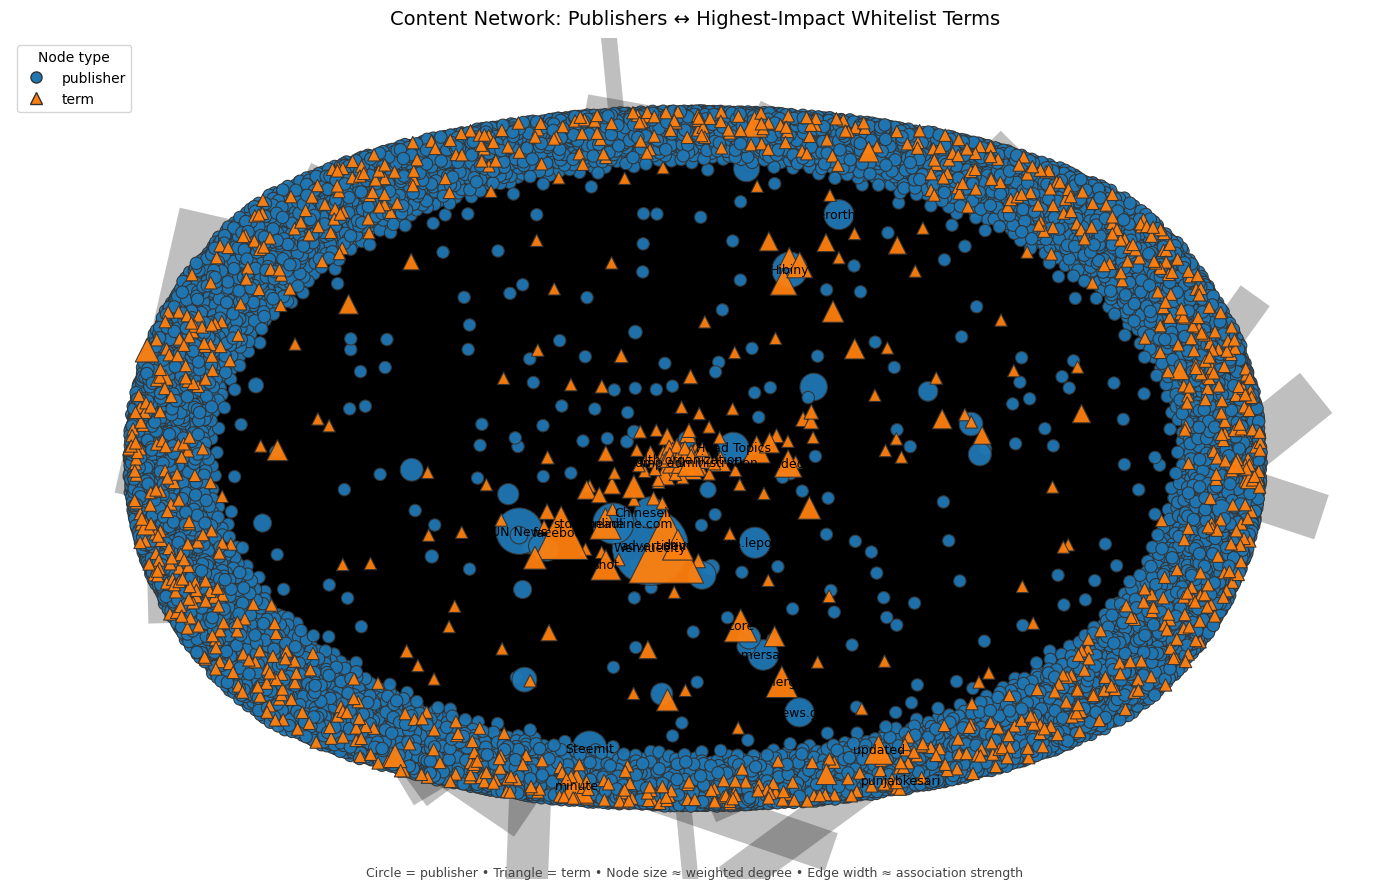

,Publisher,Term,AssocWeight
4343,Wenxuecity,advertisement,41563.105154
4149,UN News,facebook,8517.084016
41319,Steemit,minute,3966.971182
80253,std.stheadline.com,facebook,2939.003190
86233,std.stheadline.com,online,2878.001394
123993,punjabkesari,updated,2266.008932
151063,Wenxuecity,shot,2100.000000
85,Head Topics,yang,1907.015757
148481,Hibiny,daily,1800.000000
76353,Zephyrnet,talk,1644.000000


In [ ]:
# Graph + plot
# ----------------------------
def build_bipartite_graph(edges: pd.DataFrame) -> nx.Graph:
    G = nx.Graph()
    for _, r in edges.iterrows():
        p, t, w = r["publisher"], r["term"], float(r["weight"])
        if p not in G: G.add_node(p, ntype="publisher")
        if t not in G: G.add_node(t, ntype="term")
        if w > 0:
            G.add_edge(p, t, weight=w)
    return G

def draw_pub_term_network(G: nx.Graph, top_labels_per_type: int = TOP_LABELS, figsize=FIGSIZE):
    # node strength = sum of incident edge weights
    strength = {n: sum(G[n][nbr].get("weight", 0.0) for nbr in G.neighbors(n)) for n in G.nodes()}
    max_s = max(strength.values()) if strength else 1.0
    scale = lambda s: max(80.0, (s / max_s) ** 0.65 * 3000.0)

    ntype = nx.get_node_attributes(G, "ntype")
    color = {"publisher": "#1f77b4", "term": "#ff7f0e"}
    shape = {"publisher": "o", "term": "^"}

    pos = nx.spring_layout(G, k=0.6, seed=42, weight="weight")

    plt.figure(figsize=figsize)

    # edges
    widths = [max(0.5, (G[u][v]["weight"] ** 0.5) * 6) for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.25)

    # nodes by type
    for t, marker in shape.items():
        nodes_t = [n for n in G.nodes() if ntype.get(n) == t]
        nx.draw_networkx_nodes(
            G, pos, nodelist=nodes_t,
            node_size=[scale(strength[n]) for n in nodes_t],
            node_color=[color[t]] * len(nodes_t),
            node_shape=marker, linewidths=0.8, edgecolors="#333", alpha=0.95
        )

    # labels: top-N per type
    pubs = [n for n in G.nodes() if ntype.get(n) == "publisher"]
    terms = [n for n in G.nodes() if ntype.get(n) == "term"]
    pubs_top = sorted(pubs, key=lambda n: strength[n], reverse=True)[:top_labels_per_type]
    terms_top = sorted(terms, key=lambda n: strength[n], reverse=True)[:top_labels_per_type]
    labels = {n: n for n in pubs_top + terms_top}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

    plt.title("Content Network: Publishers ↔ Highest-Impact Whitelist Terms", fontsize=14, pad=10)
    plt.figtext(0.5, 0.02,
                "Circle = publisher • Triangle = term • Node size ≈ weighted degree • Edge width ≈ association strength",
                ha="center", fontsize=9, color="#444")

    legend_handles = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=color["publisher"],
               markeredgecolor='#333', label='publisher', markersize=8),
        Line2D([0],[0], marker='^', color='w', markerfacecolor=color["term"],
               markeredgecolor='#333', label='term', markersize=8),
    ]
    plt.legend(handles=legend_handles, loc='upper left', frameon=True, title='Node type')
    plt.axis("off"); plt.tight_layout(); plt.show()

G_content = build_bipartite_graph(edges)
draw_pub_term_network(G_content)

# Quick table of strongest links
display(
    edges.sort_values("weight", ascending=False)
         .head(20)
         .rename(columns={"publisher":"Publisher","term":"Term","weight":"AssocWeight"})
)

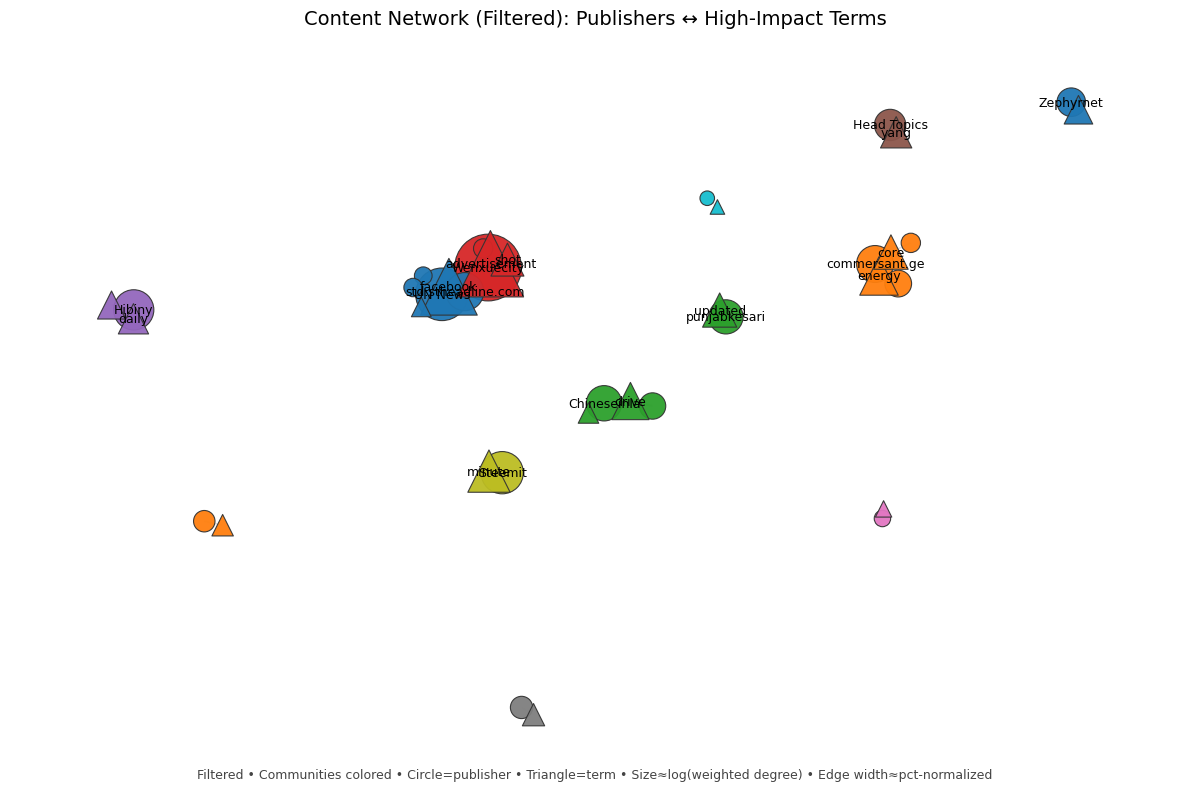

In [ ]:
# -------- sensible defaults (wider lens) --------
TOP_PUBLISHERS   = 30
TOP_TERMS        = 30
EDGE_Q_CUTOFF    = 0.75   # keep edges >= 75th percentile weight within the subset
GENERIC_TERMS    = {"online","video","link"}  # start short; add more only if noisy
LABELS_PER_TYPE  = 10
FIGSIZE          = (12, 8)

# ---- 1) start from edges, prune obvious noise but keep structure ----
ef = edges.copy()
ef = ef[~ef["term"].isin(GENERIC_TERMS)].reset_index(drop=True)

# rank endpoints by weighted degree and keep top-N of each side
pub_strength  = ef.groupby("publisher")["weight"].sum().sort_values(ascending=False)
term_strength = ef.groupby("term")["weight"].sum().sort_values(ascending=False)
keep_pubs  = set(pub_strength.head(TOP_PUBLISHERS).index)
keep_terms = set(term_strength.head(TOP_TERMS).index)
ef = ef[ef["publisher"].isin(keep_pubs) & ef["term"].isin(keep_terms)].reset_index(drop=True)

# within this subset, drop the weakest edges by percentile
if not ef.empty:
    w_cut = ef["weight"].quantile(EDGE_Q_CUTOFF)
    ef = ef[ef["weight"] >= w_cut].reset_index(drop=True)

# ---- 2) build graph and color by communities ----
G = nx.Graph()
for _, r in ef.iterrows():
    p, t, w = r["publisher"], r["term"], float(r["weight"])
    G.add_node(p, ntype="publisher")
    G.add_node(t, ntype="term")
    G.add_edge(p, t, weight=w)

if G.number_of_edges() == 0:
    print("No edges after filtering — lower EDGE_Q_CUTOFF or increase TOP_*.")
else:
    # community detection (greedy modularity)
    comms = list(greedy_modularity_communities(G, weight="weight"))
    # map node -> community index
    node2c = {}
    for i, cset in enumerate(comms):
        for n in cset: node2c[n] = i

    # node strength (weighted degree) for sizes
    strength = {n: sum(G[n][nbr].get("weight", 0.0) for nbr in G.neighbors(n)) for n in G.nodes()}
    svals = np.array(list(strength.values()))
    s_log = np.log1p(svals)
    smin, smax = float(s_log.min()), float(s_log.max())
    def nsize(n, base=110, span=2200):
        if smax - smin < 1e-9: return base + span * 0.5
        x = (np.log1p(strength[n]) - smin) / (smax - smin)
        return base + span * x

    # edge widths normalized by percentile to avoid “ribbons”
    ws = np.array([float(G[u][v].get("weight", 0.0)) for u,v in G.edges()])
    p10, p90 = np.quantile(ws, [0.10, 0.90]) if len(ws) else (0, 1)
    denom = max(p90 - p10, 1e-9)
    widths = [0.8 + 4.0 * max(0, min(1, (G[u][v]["weight"] - p10)/denom)) for u,v in G.edges()]

    # palette per community
    base_colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
                   "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"]
    node_colors = [base_colors[node2c.get(n, 0) % len(base_colors)] for n in G.nodes()]

    # nicer layout for mid-sized graphs
    pos = nx.spring_layout(G, k=0.6, seed=42, weight="weight")

    # draw
    plt.figure(figsize=FIGSIZE)
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.20, edge_color="#666")

    pubs  = [n for n,d in G.nodes(data=True) if d.get("ntype") == "publisher"]
    terms = [n for n,d in G.nodes(data=True) if d.get("ntype") == "term"]

    nx.draw_networkx_nodes(G, pos, nodelist=pubs,
                           node_size=[nsize(n) for n in pubs],
                           node_color=[node_colors[list(G.nodes()).index(n)] for n in pubs],
                           node_shape="o", linewidths=0.8, edgecolors="#333", alpha=0.95)
    nx.draw_networkx_nodes(G, pos, nodelist=terms,
                           node_size=[nsize(n) for n in terms],
                           node_color=[node_colors[list(G.nodes()).index(n)] for n in terms],
                           node_shape="^", linewidths=0.8, edgecolors="#333", alpha=0.95)

    # label strongest few per side
    pubs_top  = sorted(pubs,  key=lambda n: strength[n], reverse=True)[:LABELS_PER_TYPE]
    terms_top = sorted(terms, key=lambda n: strength[n], reverse=True)[:LABELS_PER_TYPE]
    labels = {n: n for n in pubs_top + terms_top}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

    plt.title("Content Network (Filtered): Publishers ↔ High-Impact Terms", fontsize=14, pad=10)
    plt.figtext(0.5, 0.02,
        "Filtered • Communities colored • Circle=publisher • Triangle=term • Size≈log(weighted degree) • Edge width≈pct-normalized",
        ha="center", fontsize=9, color="#444")
    plt.axis("off"); plt.tight_layout(); plt.show()

In [ ]:
 # ===============================================
# Community summary with representative edges
# ===============================================
import pandas as pd
from IPython.display import display

def summarize_communities_with_examples(G, edges_df_conv, node2c, top_k=5, top_edges=1):
    """
    For each community:
      - top_k terms by weighted degree
      - top_k publishers by weighted degree
      - top_edges strongest Publisher–Term links (representative edges)
    Returns a tidy DataFrame.
    """
    # Keep only edges that exist in the current graph (after filtering)
    nodes_in_G = set(G.nodes())
    e = edges_df_conv[
        edges_df_conv["publisher"].isin(nodes_in_G) & edges_df_conv["term"].isin(nodes_in_G)
    ].copy()

    rows = []
    for cid in sorted(set(node2c.values())):
        nodes_c  = {n for n, k in node2c.items() if k == cid}
        pubs_c   = {n for n in nodes_c if G.nodes[n].get("ntype") == "publisher"}
        terms_c  = {n for n in nodes_c if G.nodes[n].get("ntype") == "term"}

        # restrict to edges internal to the community
        ec = e[e["publisher"].isin(pubs_c) & e["term"].isin(terms_c)]
        if ec.empty:
            continue

        # top terms/publishers by weighted degree within this community
        term_strength = (ec.groupby("term")["weight"].sum()
                           .sort_values(ascending=False))
        pub_strength  = (ec.groupby("publisher")["weight"].sum()
                           .sort_values(ascending=False))

        # representative edges (strongest)
        top_edge_rows = (ec.sort_values("weight", ascending=False)
                           .head(top_edges)
                           .assign(example=lambda d: d["publisher"] + " — " + d["term"] +
                                                   " (" + d["weight"].round(1).astype(str) + ")"))
        examples = "; ".join(top_edge_rows["example"].tolist())

        rows.append({
            "Community": cid,
            "Top Terms": ", ".join(term_strength.head(top_k).index),
            "Top Publishers": ", ".join(pub_strength.head(top_k).index),
            "Representative Edge(s)": examples,
            "Edges in Community": len(ec),
            "Total Weight": ec["weight"].sum().round(1)
        })

    return (pd.DataFrame(rows)
              .sort_values(["Total Weight","Edges in Community"], ascending=False)
              .reset_index(drop=True))

# Build and show the summary table
comm_summary = summarize_communities_with_examples(
    G, ef, node2c, top_k=5, top_edges=1  # set top_edges=3 to show top-3 examples per community
)
display(comm_summary)

,Community,Top Terms,Top Publishers,Representative Edge(s),Edges in Community,Total Weight
0,3,"advertisement, shot","Wenxuecity, News.leportale",Wenxuecity — advertisement (41563.1),3,44763.5
1,0,"facebook, jean","UN News, std.stheadline.com, ექსკლუზივ ნიუს, I...",UN News — facebook (8517.1),5,14679.1
2,1,"energy, core","commersant.ge, News.ge, News Hub",commersant.ge — energy (1500.0),4,5300.0
3,8,minute,Steemit,Steemit — minute (3967.0),1,3967.0
4,2,"drive, rsv","Chineseinla, Ambebi.ge",Ambebi.ge — drive (1473.0),3,3908.0
5,4,"daily, big",Hibiny,Hibiny — daily (1800.0),2,3400.0
6,12,updated,punjabkesari,punjabkesari — updated (2266.0),1,2266.0
7,5,yang,Head Topics,Head Topics — yang (1907.0),1,1907.0
8,10,talk,Zephyrnet,Zephyrnet — talk (1644.0),1,1644.0
9,7,nursing,Cedar News,Cedar News — nursing (1230.0),1,1230.0
